<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Read in dataset
df = pd.read_csv('/content/drive/MyDrive/Python Course/EasyVisa.csv')

# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
#Check first 5 rows of dataset
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
#Check last 5 rows of dataset
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


First and last five rows read ok from loaded csv file.

In [ ]:
#Check number of rows and columns in dataset
df.shape

(25480, 12)

Data frame has a shape of 25,480 rows and 12 columns.

In [ ]:
#Check data types in data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


Objects - case_id, continent, education_of_employees, has_job_experience, requires_job_training, region_of_employment, unit_of_wage, full_time_position, case_status

int - no_of_employees, yr_of_estab

float - prevailing_wage

In [ ]:
#Check high level statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


Number of employees has a median of 2109 with a minimum of -26 and maximum of 602,069. Both the minimum and maximum values here don't make much sense and outliers for this column will need to be checked.

Year of establishment has a median year of 1997 with minimum at 1800 and maximum at 2016.

The prevailing wage has a median of 70,308 with a max of 319,210 and minimum of 2.137. The minimum salary here seems abnormally low and may need to be checked.

In [ ]:
#Check for null data
df.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [ ]:
#Check for duplicate data
df.duplicated().sum()

np.int64(0)

The dataset contains no null values and no duplicate values.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

## Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
    plt.show()

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def labeled_barplot2(data, feature1, feature2, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature1])  # length of the column
    count = data[feature1].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature1,
        hue=feature2,
        order=data[feature1].value_counts().index[:n],
    )

    for p in ax.patches[:-2]:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.title(f'{feature1} vs {feature2}')

    plt.show()  # show the plot

Variable Name: continent:


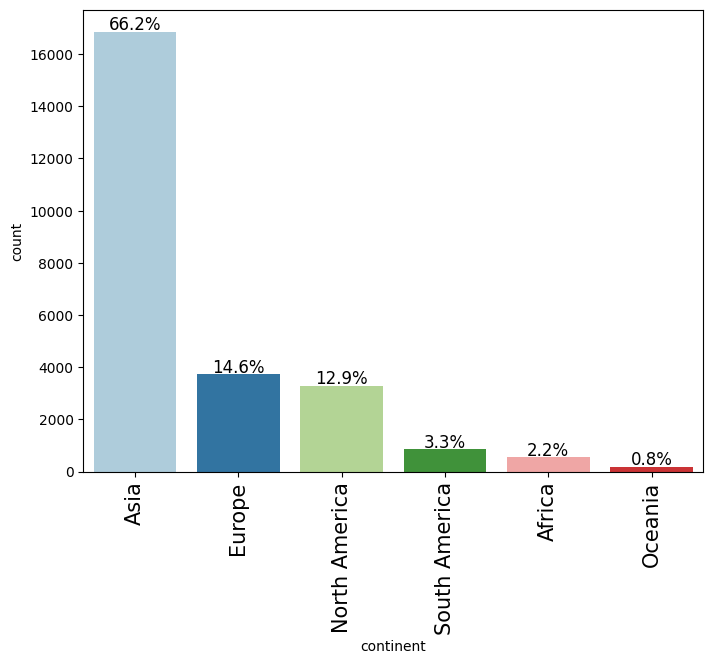



-----------------------------------------------------------------


Variable Name: education_of_employee:


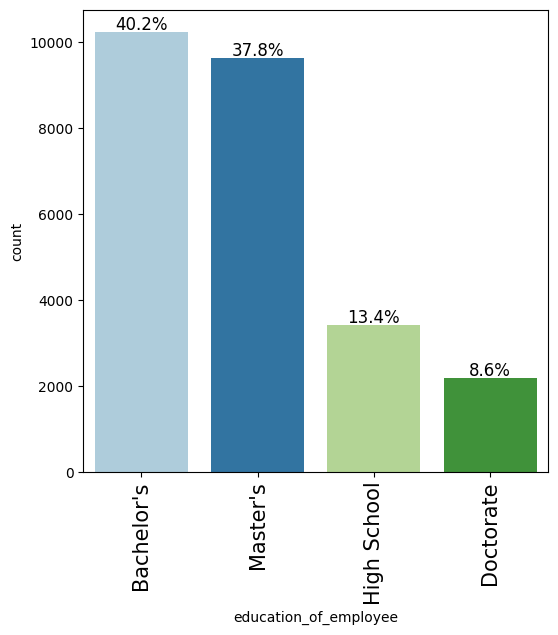



-----------------------------------------------------------------


Variable Name: has_job_experience:


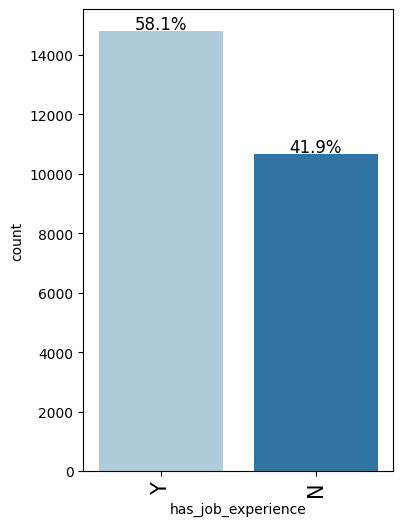



-----------------------------------------------------------------


Variable Name: requires_job_training:


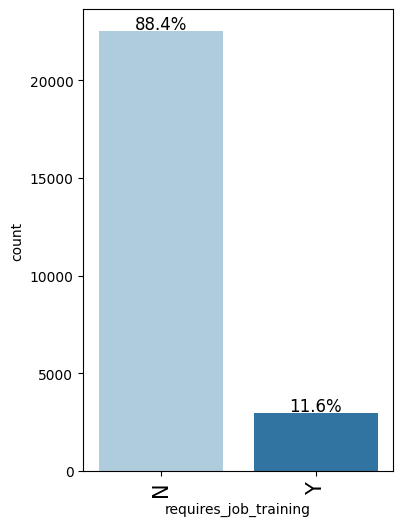



-----------------------------------------------------------------


Variable Name: no_of_employees:


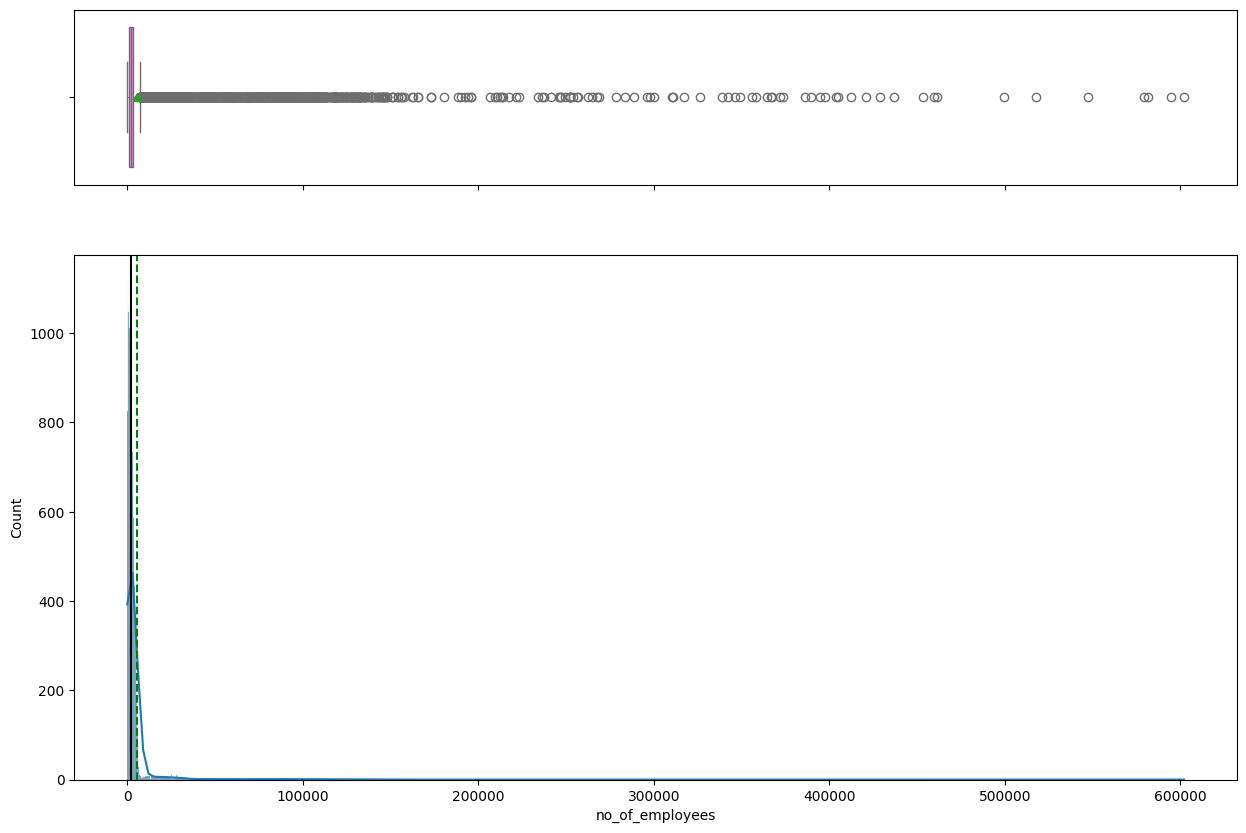



-----------------------------------------------------------------


Variable Name: yr_of_estab:


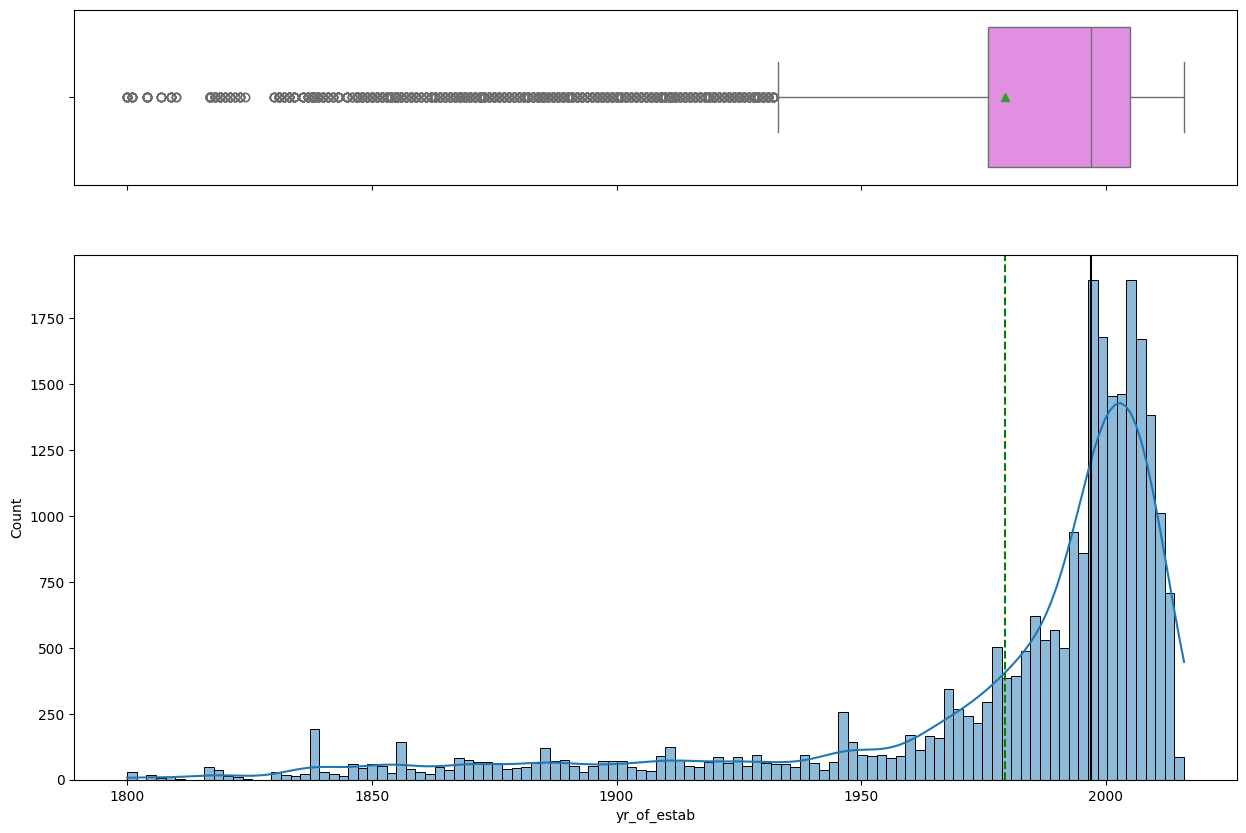



-----------------------------------------------------------------


Variable Name: region_of_employment:


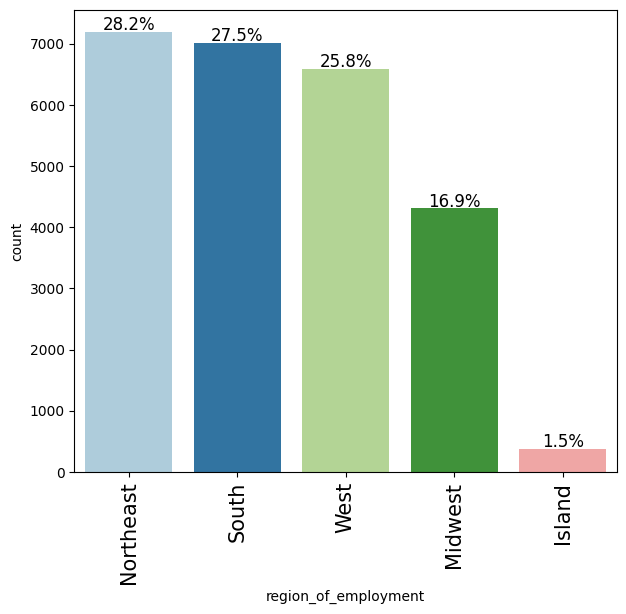



-----------------------------------------------------------------


Variable Name: prevailing_wage:


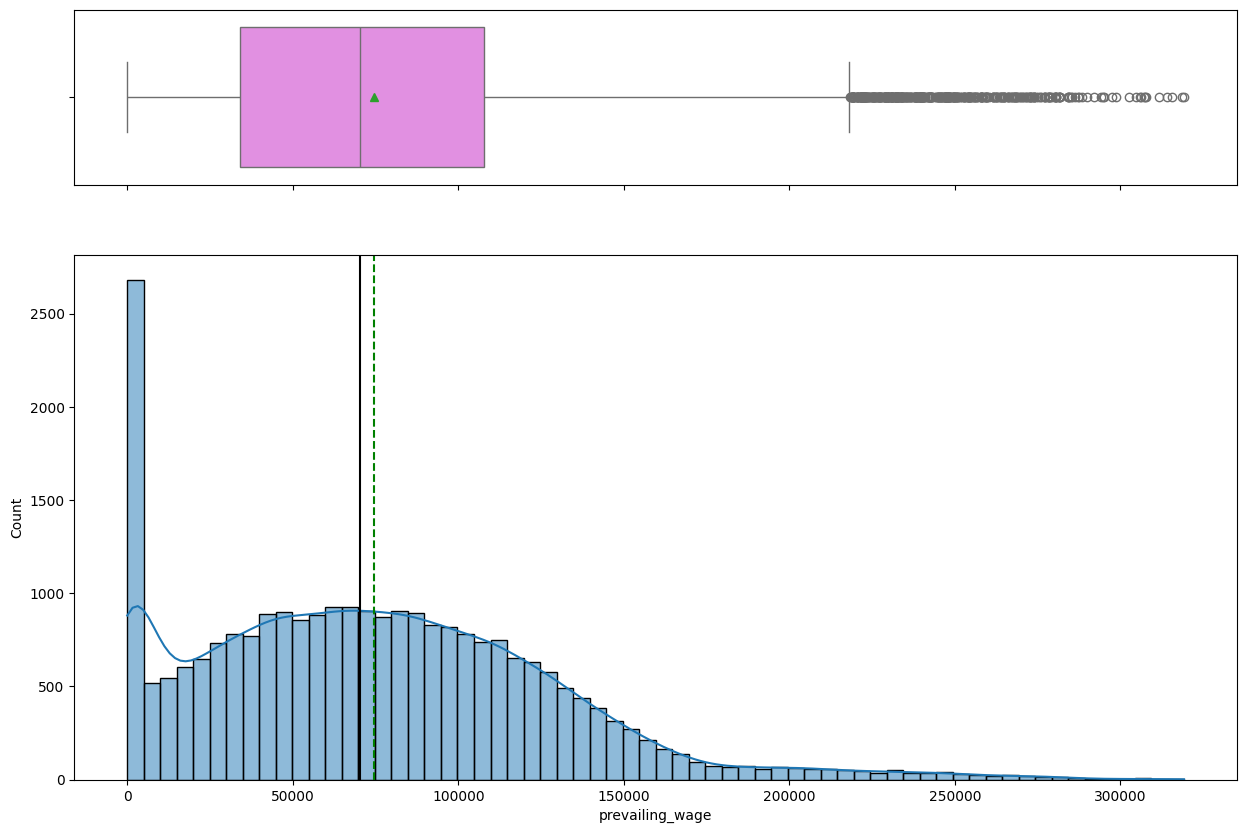



-----------------------------------------------------------------


Variable Name: unit_of_wage:


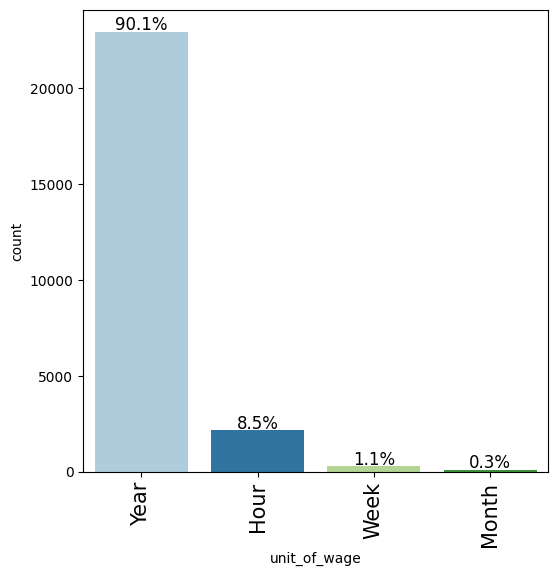



-----------------------------------------------------------------


Variable Name: full_time_position:


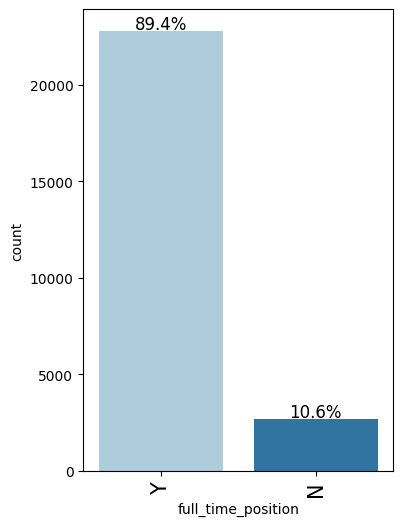



-----------------------------------------------------------------


Variable Name: case_status:


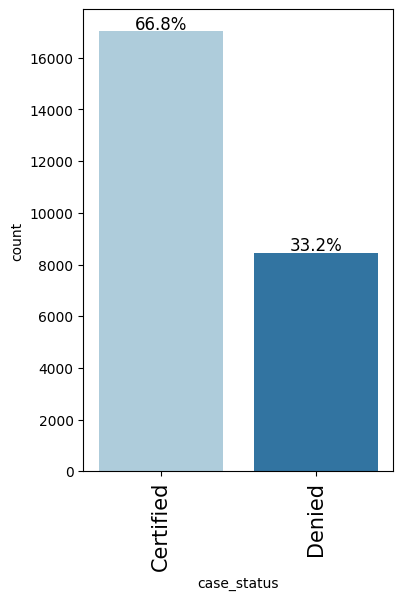



-----------------------------------------------------------------




In [ ]:
#Run univariate analysis for all variables
columns = df.columns
for col in columns[1:]:
  print(f'Variable Name: {col}:')
  if df[col].dtype == 'object':
    labeled_barplot(df, col, perc=True)
  else:
    histogram_boxplot(df, col, kde=True)

  print('\n\n-----------------------------------------------------------------\n\n')

- **Continent:** The majority of applicants come from Asia at 66.2% followed by Europe and North America at 14.6% and 12.9% respectively. South America, Africa and Oceania combined make up 6.3% of applicants.

<br>

- **Education of Employee:** The majority of applicants have either a bachelor's or master's degree (combined at 78%). The rest having high school education or a Doctorate.

<br>

- **Has Job Experience:** 58.1% of applicants have job experience while 41.9% do not have job experience.

<br>

- **Requires Job Training:** 88.4% of applicants do not require training while 11.6% do require it.

<br>

- **Number of Employees:** Number of employees is highly skewed right with values as high as 600,000. <u>*These outliers seem to be unreasonable and will more than likely need to be removed before proceeding.*</u>

<br>

- **Year of Establishment:** The vast majority of companies were founded after 1950 with the median founding date in the late 1990s. <u>*Data is highly skewed left and may need to have a closer look to validate outliers make sense.*</u>

<br>

- **Region of Employment:** Employent in the Northeast, South and West are similar with roughly 25% each. Followed by the midwest and a small number in the Islands.

<br>

- **Prevailing Wage:** The median prevailing wage is around 70,000 with the data slightly skewed right. <u>*0 seems to have abnormally high values and imputation will probably need to be done here.*</u>

<br>

- **Unit of Wage:** 90.1% ofwage unit is by year, followed by hourly. Weekly and monthly make up a small percentage of the total (1.4% combined).

<br>

- **Full Time Position:** 89.4% of the positions are full time with the rest not being full time.

<br>

- **Case Status:** 66.8% of case status are certified while 33.2% are denied. ***This answers question 1 of the leading questions section.***

## Bivariate

### Leading Questions

####2. How does the education level of employees impact visa approval rates?


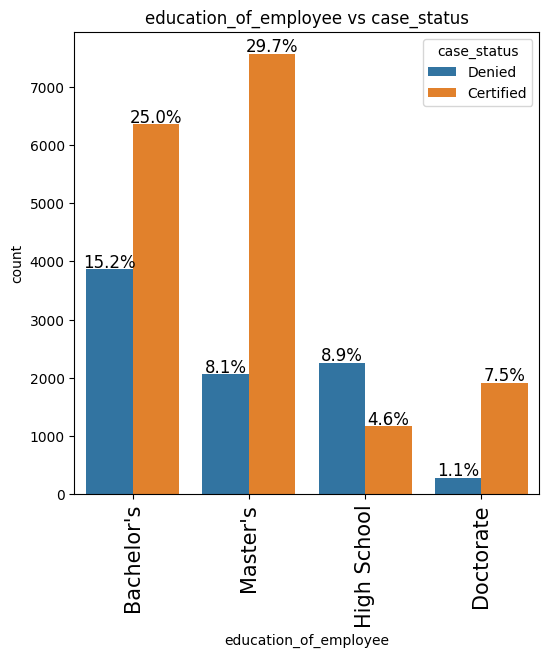

In [ ]:
#Barplot of education level and case status
labeled_barplot2(df, 'education_of_employee', 'case_status', perc=True)

In [ ]:
#Table showing the percentage of Certified and Denied Visas for each education level group
ed_counts = (df.groupby('education_of_employee')['case_status'].value_counts() / df.groupby('education_of_employee')['case_status'].count()) * 100
ed_counts

education_of_employee  case_status
Bachelor's             Certified     62.214
                       Denied        37.786
Doctorate              Certified     87.226
                       Denied        12.774
High School            Denied        65.965
                       Certified     34.035
Master's               Certified     78.628
                       Denied        21.372
dtype: float64

A bachelor's, Masters, and Doctroate degree increase the chances of the visa being certified.

For high school education, there are more denials than certified visas.

This is the case when considering total cases and cases per education level.

#### 3. Is there a significant difference in visa approval rates between employees with and without prior job experience?


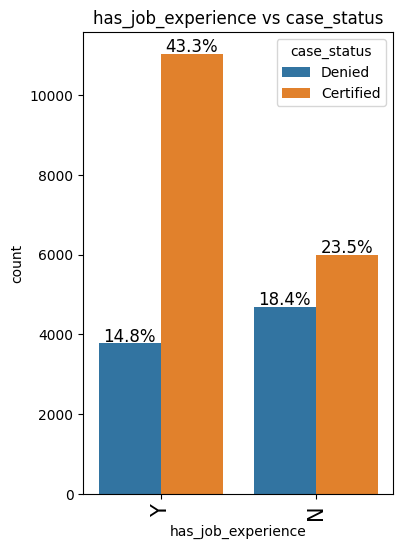

In [ ]:
#Barplot of job experience and case status
labeled_barplot2(df, 'has_job_experience', 'case_status', perc=True)

In [ ]:
#Table showing the percentage of Certified and Denied Visas for each job experience group
je_counts = (df.groupby('has_job_experience')['case_status'].value_counts() / df.groupby('has_job_experience')['case_status'].count()) * 100
je_counts

has_job_experience  case_status
N                   Certified     56.134
                    Denied        43.866
Y                   Certified     74.476
                    Denied        25.524
dtype: float64

If the applicant for the visa has job expereince more often than not the visa was certified. This is the case for total and cases and the cases for has job experience alone and no job experience alone.

#### 4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?


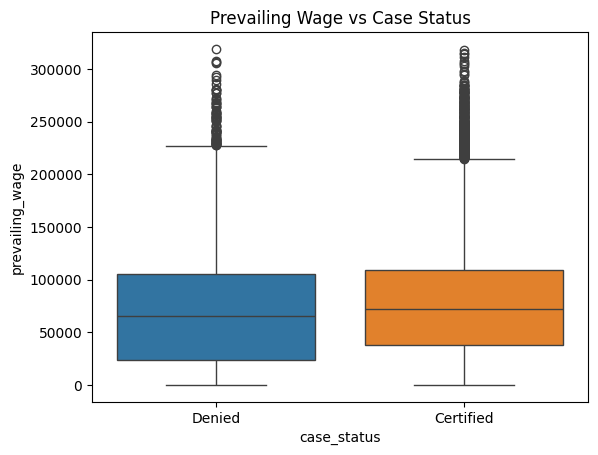

In [ ]:
#Boxplot of Prevailing Wage and case status
sns.boxplot(data=df, x='case_status', y='prevailing_wage', hue='case_status')
plt.title('Prevailing Wage vs Case Status')
plt.show()

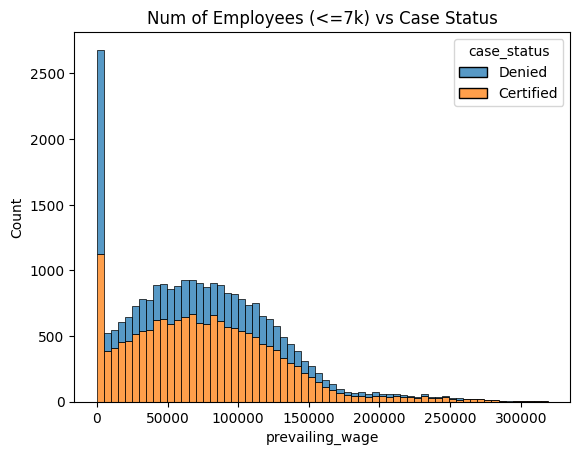

In [ ]:
#Histplot of prevailing wage and case status
sns.histplot(data=df, x='prevailing_wage', hue='case_status', multiple='stack')
plt.title('Num of Employees (<=7k) vs Case Status')
plt.show()

Based on the above boxplot there isn't strong evidence to suggest a higher prevailing wage will lead to higher chances of approval. The certified median is slightly higher than the denied but generally both plots are fairly close to one another.

#### 5. Do certain regions in the US have higher visa approval rates compared to others?


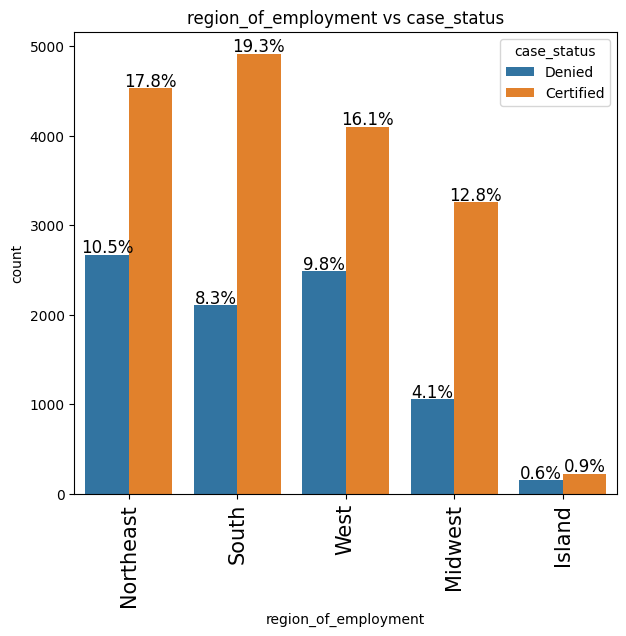

In [ ]:
#Barplot of each region and the counts of certified and denied visas
labeled_barplot2(df, 'region_of_employment', 'case_status', perc=True)

In [ ]:
#Table showing the percentage of Certified and Denied Visas for each region group
region_counts = (df.groupby('region_of_employment')['case_status'].value_counts() / df.groupby('region_of_employment')['case_status'].count()) * 100
region_counts

region_of_employment  case_status
Island                Certified     60.267
                      Denied        39.733
Midwest               Certified     75.528
                      Denied        24.472
Northeast             Certified     62.905
                      Denied        37.095
South                 Certified     70.016
                      Denied        29.984
West                  Certified     62.253
                      Denied        37.747
dtype: float64

When considering total applications the south appears to have the largest approval rate compared to any other region. Not far behind though are the Northeast and West.

When considering each regions percentage of certified and denied visas, the midwest has the largest approval rate at 75.5%.

#### 6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?


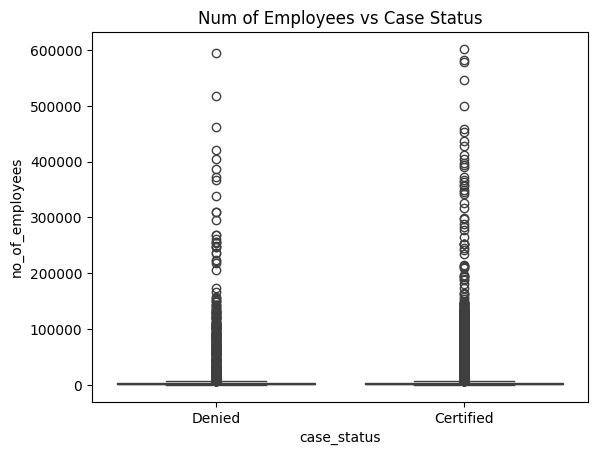

In [ ]:
#Boxplot of Prevailing Wage and case status (all number of employees)
sns.boxplot(data=df, x='case_status', y='no_of_employees', hue='case_status')
plt.title('Num of Employees vs Case Status')
plt.show()

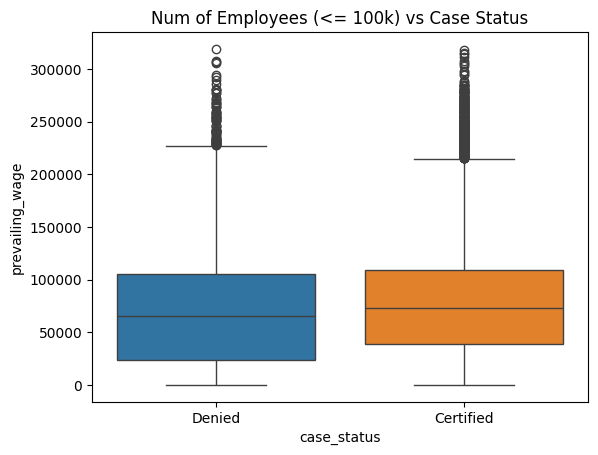

In [ ]:
#Boxplot of Prevailing Wage and case status (companies of 100,000 employees or less)
sns.boxplot(data=df[df['no_of_employees'] <= 100000], x='case_status', y='prevailing_wage', hue='case_status')
plt.title('Num of Employees (<= 100k) vs Case Status')
plt.show()

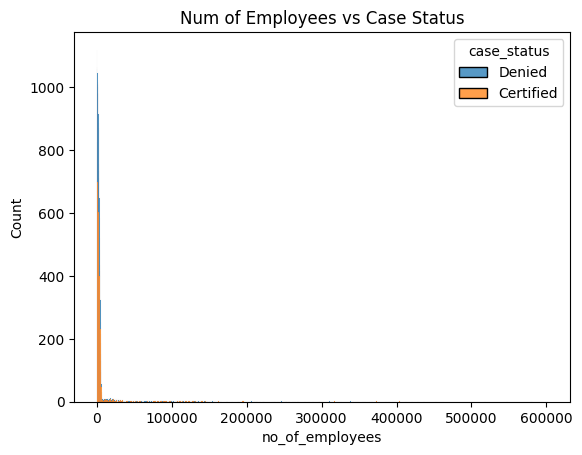

In [ ]:
#Histplot of Certified and denied visas including all number of employees
sns.histplot(data=df, x='no_of_employees', hue='case_status', multiple='stack')
plt.title('Num of Employees vs Case Status')
plt.show()

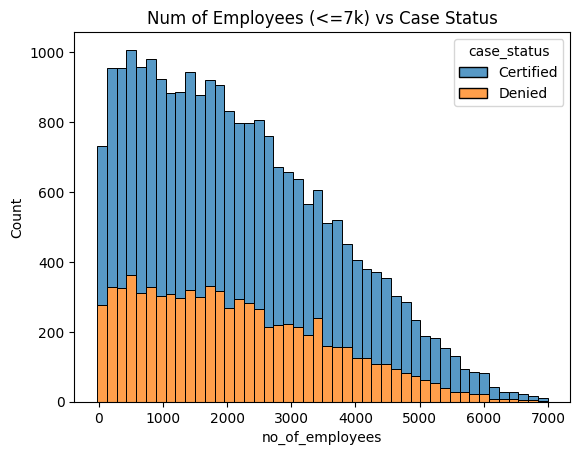

In [ ]:
#Histplot of Certified and denied visas including only number of employees less than or equal to 7000
sns.histplot(data=df[df['no_of_employees'] <= 7000], x='no_of_employees', hue='case_status', multiple='stack')
plt.title('Num of Employees (<=7k) vs Case Status')
plt.show()

The ratio of certified and denied visas seems comprable from small companies to large companies.

Notable is that the count of both certified and denied visas is higher for smaller companies and decreases the more emplyees that belong to a company.

#### 7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

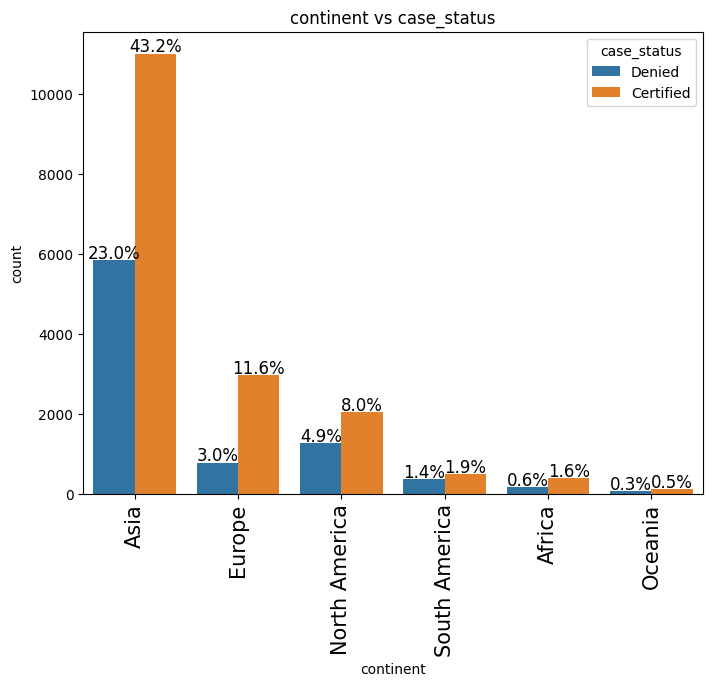

In [ ]:
#Barplot showing the count of certified and denied visas for each country
labeled_barplot2(df, 'continent', 'case_status', perc=True)

In [ ]:
#Table showing the percentage of Certified and Denied Visas for each continent group
continent_counts = (df.groupby('continent')['case_status'].value_counts() / df.groupby('continent')['case_status'].count()) * 100
continent_counts


continent      case_status
Africa         Certified     72.051
               Denied        27.949
Asia           Certified     65.310
               Denied        34.690
Europe         Certified     79.234
               Denied        20.766
North America  Certified     61.877
               Denied        38.123
Oceania        Certified     63.542
               Denied        36.458
South America  Certified     57.864
               Denied        42.136
dtype: float64

Based on the total count of certified and denied visa applications per country, Asia has the most approvals with 43.2% of the total. The lowest is Oceania with 0.5%.

Based on certified and denied visas for each continent, Europe has the highest approval with 79.2%. South America has the lowest with 57.9%.

### Prevailing Wage vs Unit of Wage Investigation

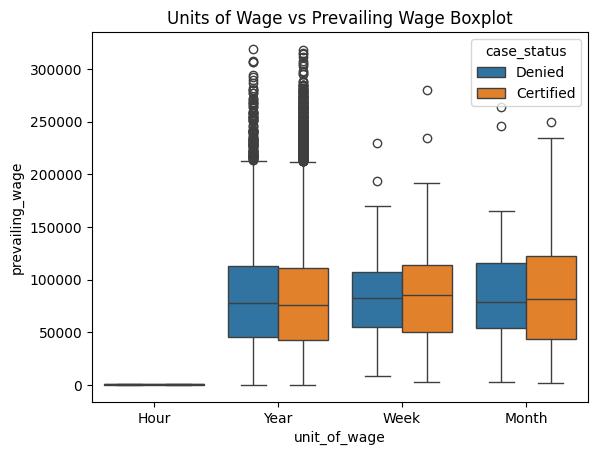

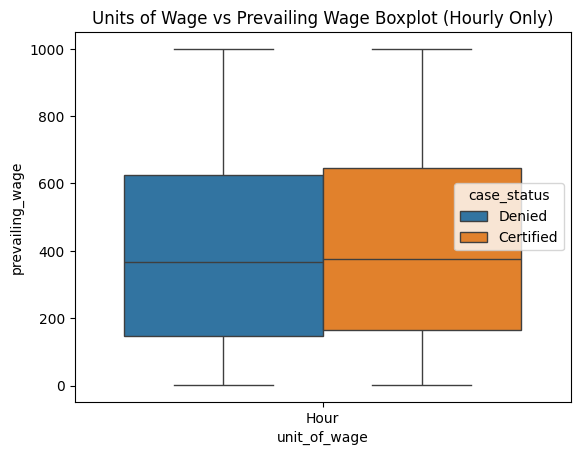

In [ ]:
#Check boxplot of unit of wage vs prevailing wage
sns.boxplot(data=df, x='unit_of_wage', y='prevailing_wage', hue='case_status')
plt.title('Units of Wage vs Prevailing Wage Boxplot')
plt.show()
sns.boxplot(data=df[df['unit_of_wage'] == 'Hour'], x='unit_of_wage', y='prevailing_wage', hue='case_status')
plt.title('Units of Wage vs Prevailing Wage Boxplot (Hourly Only)')
plt.show()

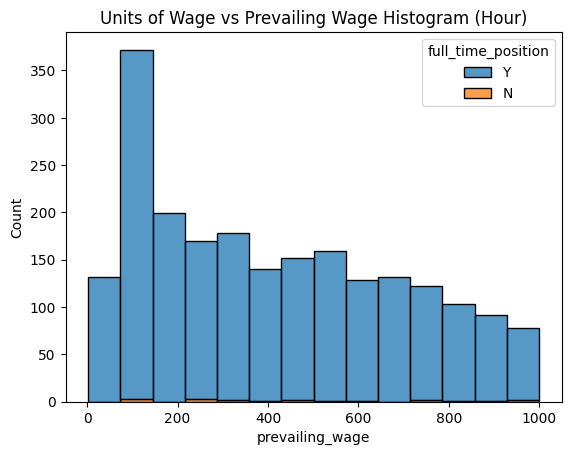

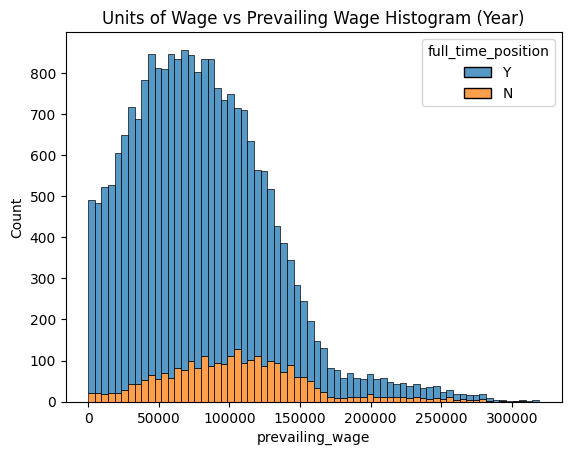

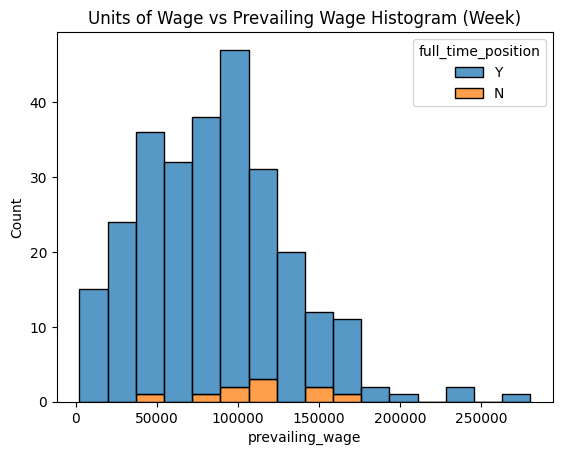

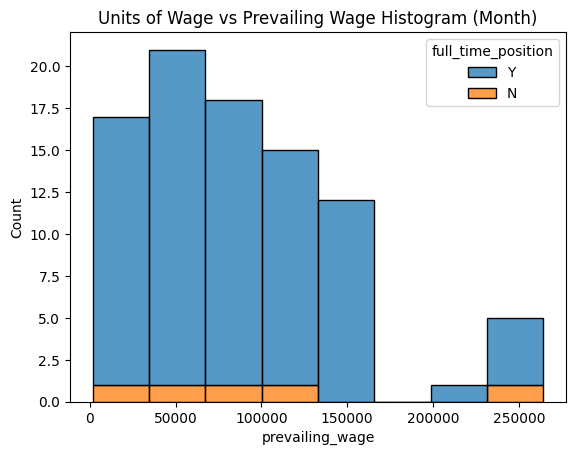

In [ ]:
#Check distribution of individual unit of wage variables vs prevailing wage
units_wage = df['unit_of_wage'].unique()
legend_order = ['Y', 'N']

for unit in units_wage:
  sns.histplot(data=df[df['unit_of_wage'] == unit], x='prevailing_wage', hue='full_time_position', multiple='stack', hue_order=legend_order)
  plt.title(f'Units of Wage vs Prevailing Wage Histogram ({unit})')
  plt.show()

Further investigation into the low prevailing wage numbers, it is heavily driven by the hourly wage applicants. The values look reasonable when evaluating hourly on its own though it heavily skews the prevailing wage variable to the left.

Based on project FAQ, it is not necessary to normalize these values. Values also seem reasonable for the respective units. We will therefore proceed with caution.

No strong correlations of numeric variables. Interesting insights from the remaining gcategorical data that can be taken into consideration when building model

### Number of Employees Investigation

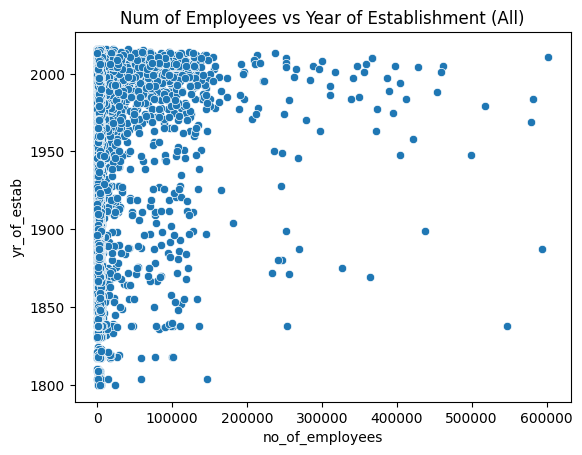

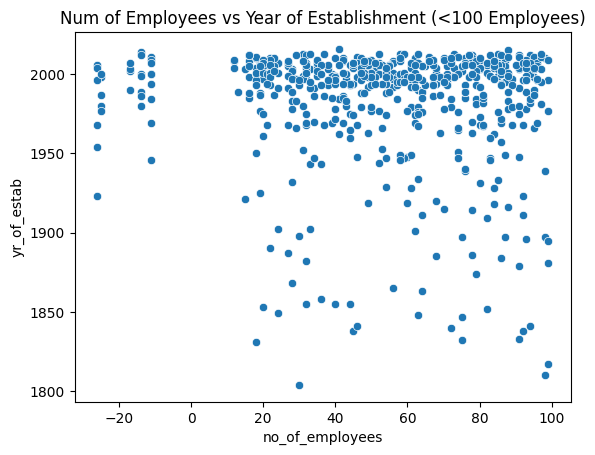

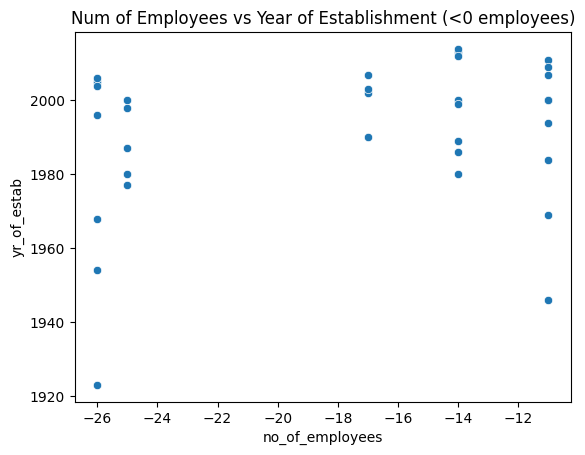

In [ ]:
#Create scatter plots of year company was established vs number of employees to check for anomalous values
sns.scatterplot(data=df, x='no_of_employees', y='yr_of_estab')
plt.title('Num of Employees vs Year of Establishment (All)')
plt.show()
sns.scatterplot(data=df[df['no_of_employees'] < 100], x='no_of_employees', y='yr_of_estab')
plt.title('Num of Employees vs Year of Establishment (<100 Employees)')
plt.show()
sns.scatterplot(data=df[df['no_of_employees'] < 0], x='no_of_employees', y='yr_of_estab')
plt.title('Num of Employees vs Year of Establishment (<0 employees)')
plt.show()

After doing research on companies with largest amount of employees, it is plausible to have companies with around the max number of employees in our dataset (~600,000) and lower. Therefore these outlier will not be touched.

Negative numbers of employees however is not possible. The easiest imputation would be to assume the data entry was input with a negative number and do absolute value of the negative numbers.

### Other Analysis

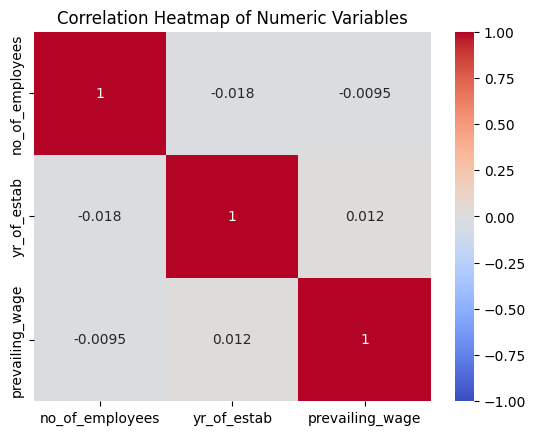

In [ ]:
#Check for correlations between numeric variables
sns.heatmap(data=df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

No strong correlations observed between the numeric variables.

In [ ]:
#Save object columns to variable
obj_columns = df.select_dtypes('object').columns
obj_columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

Variable Name: continent:


-----------------------------------------------------------------




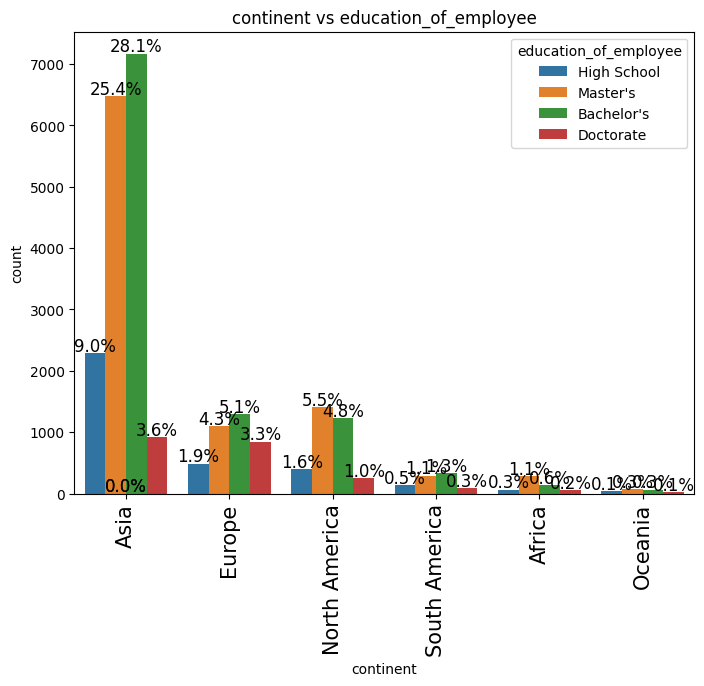



-----------------------------------------------------------------




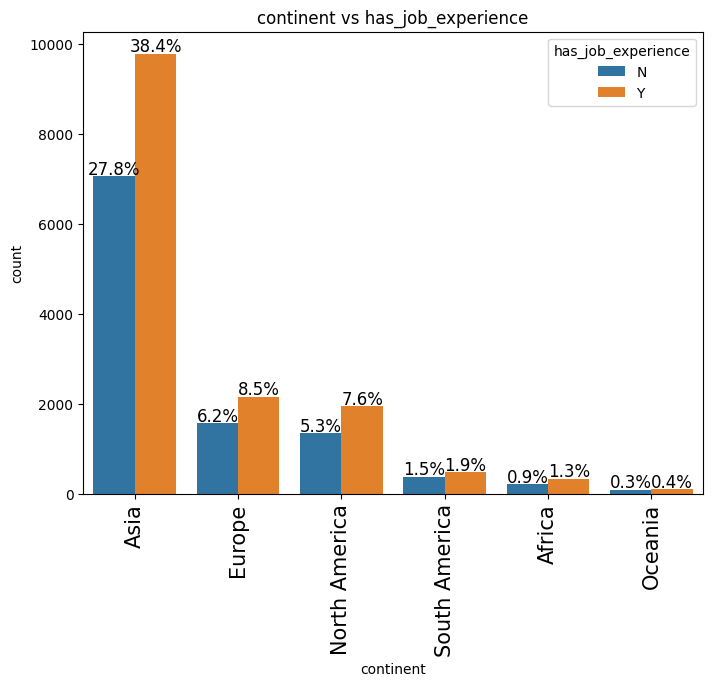



-----------------------------------------------------------------




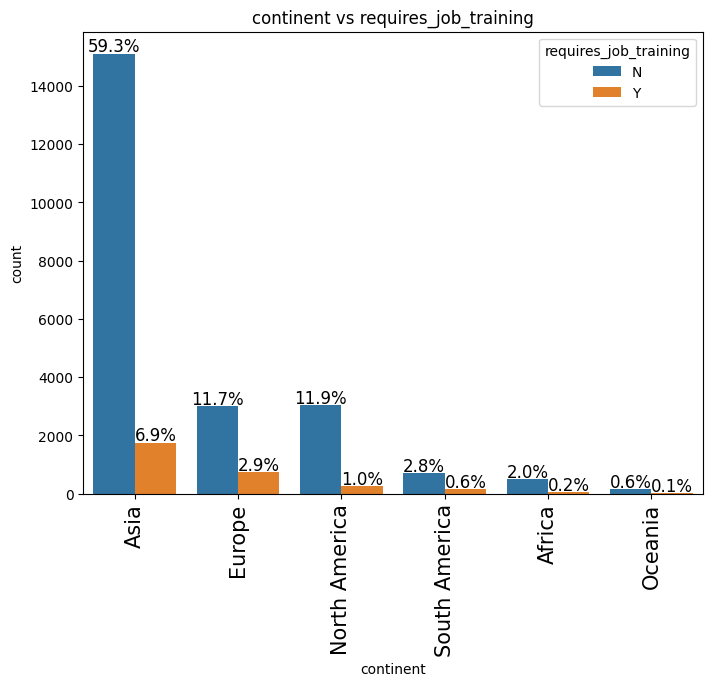



-----------------------------------------------------------------




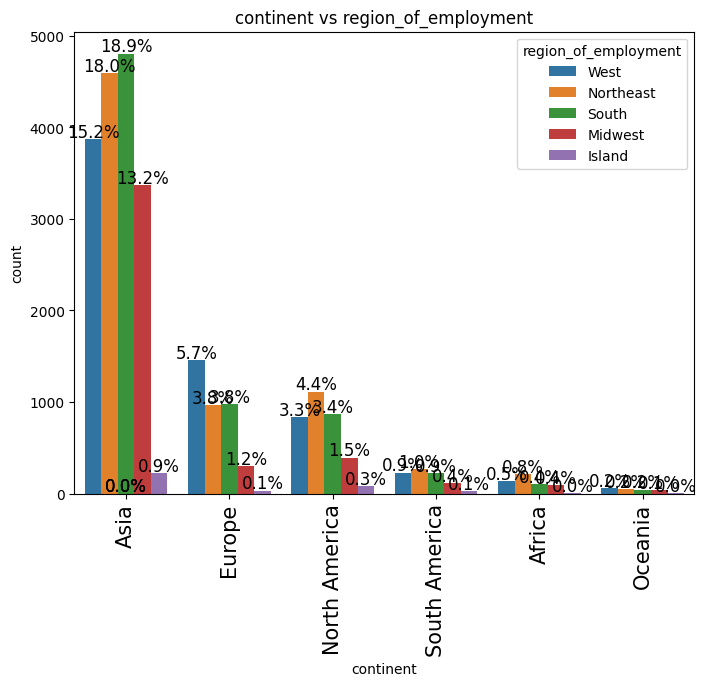



-----------------------------------------------------------------




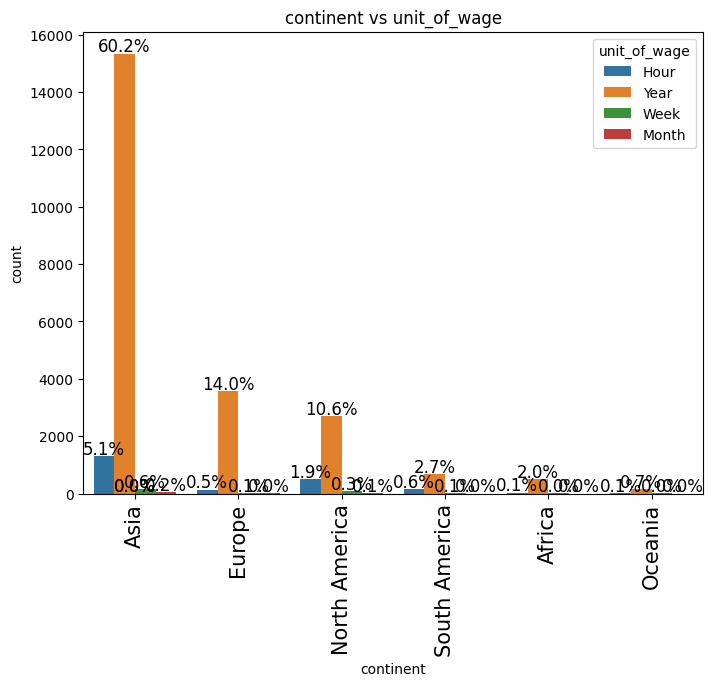



-----------------------------------------------------------------




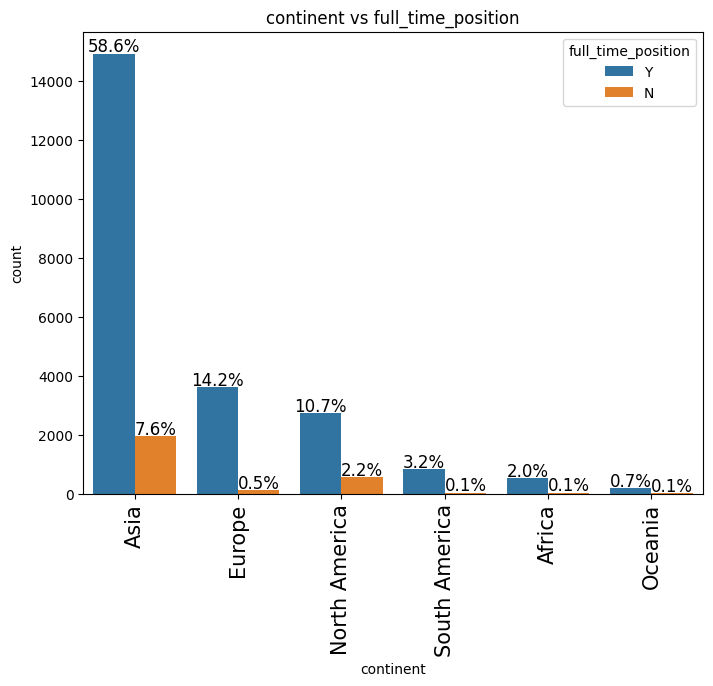



-----------------------------------------------------------------


Variable Name: education_of_employee:


-----------------------------------------------------------------




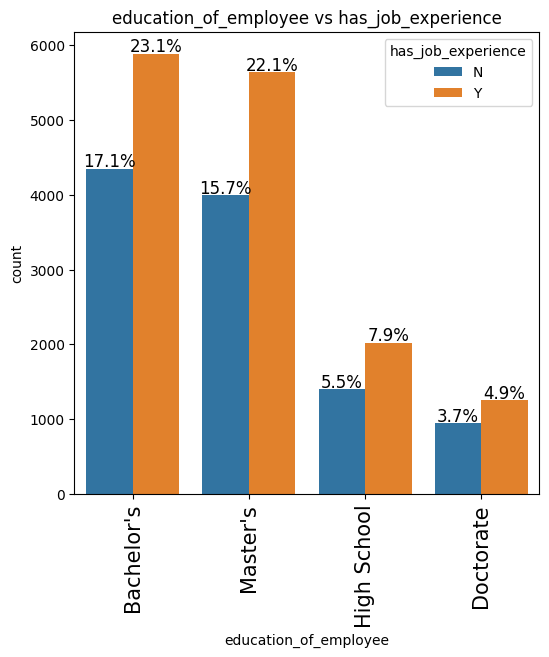



-----------------------------------------------------------------




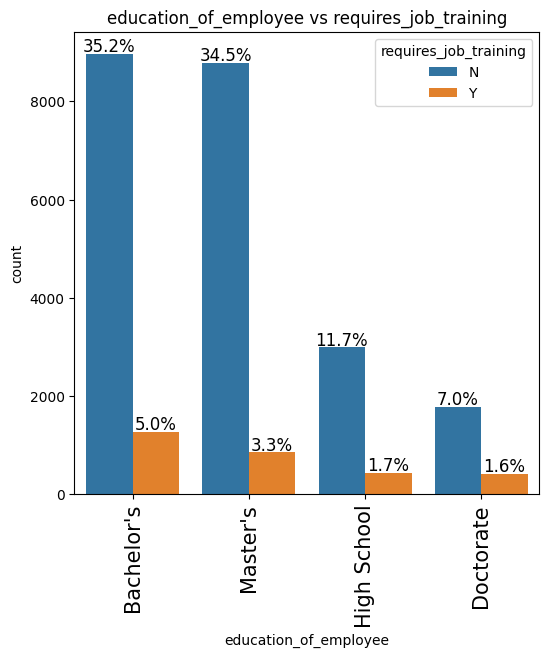



-----------------------------------------------------------------




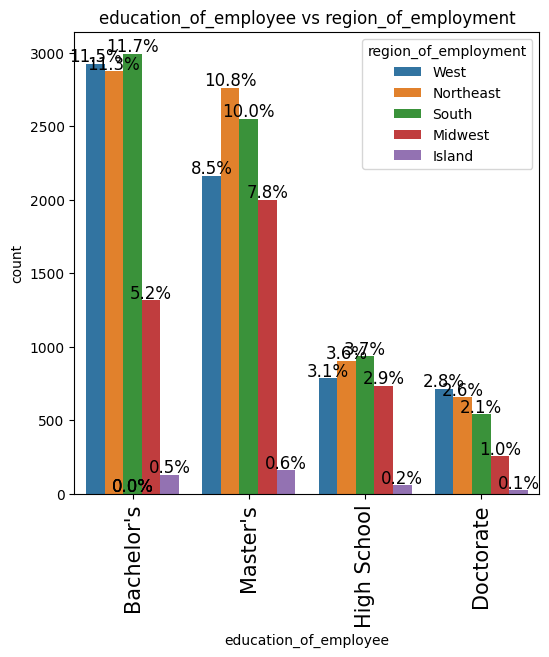



-----------------------------------------------------------------




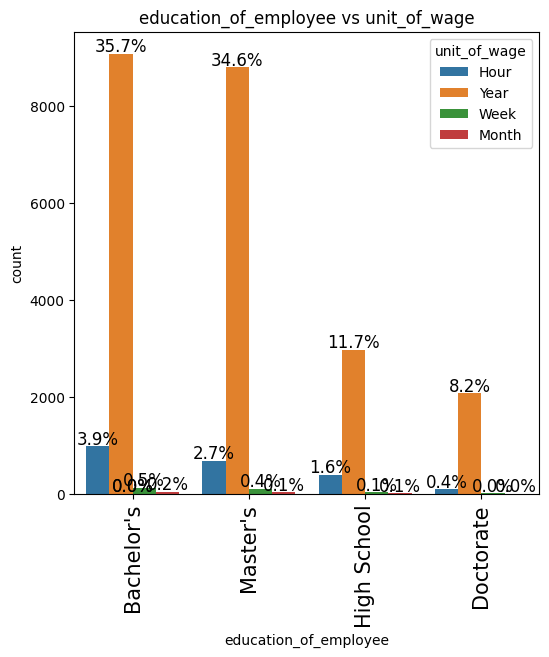



-----------------------------------------------------------------




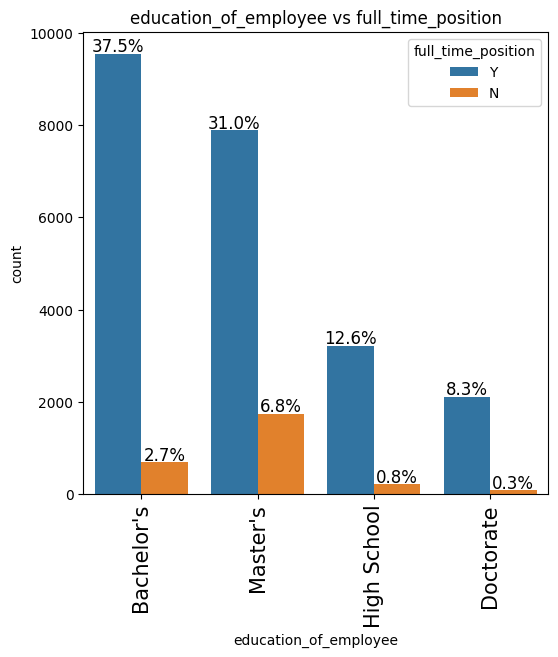



-----------------------------------------------------------------


Variable Name: has_job_experience:


-----------------------------------------------------------------




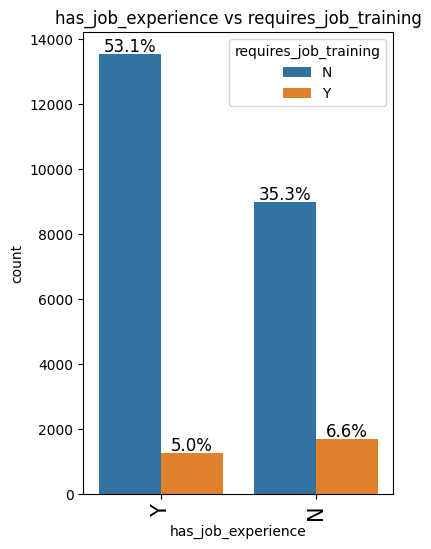



-----------------------------------------------------------------




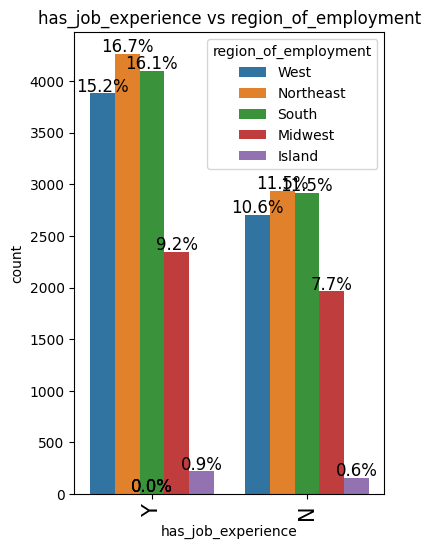



-----------------------------------------------------------------




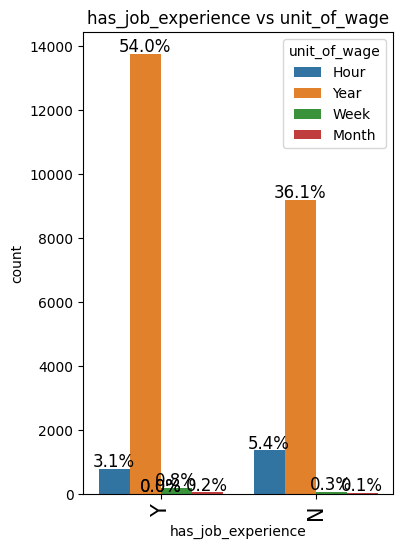



-----------------------------------------------------------------




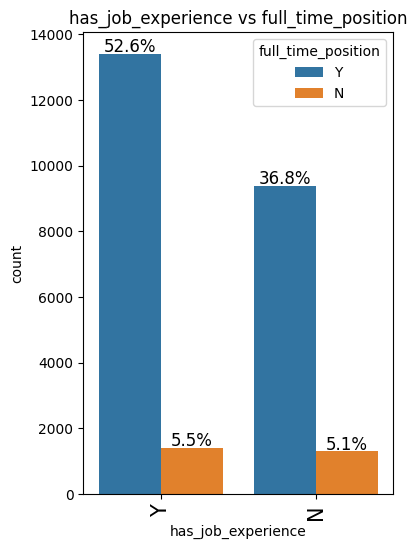



-----------------------------------------------------------------


Variable Name: requires_job_training:


-----------------------------------------------------------------




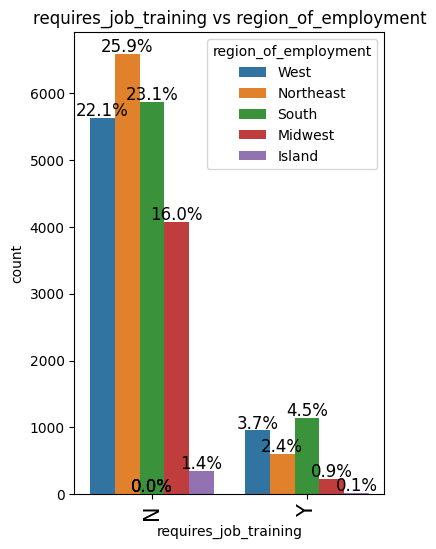



-----------------------------------------------------------------




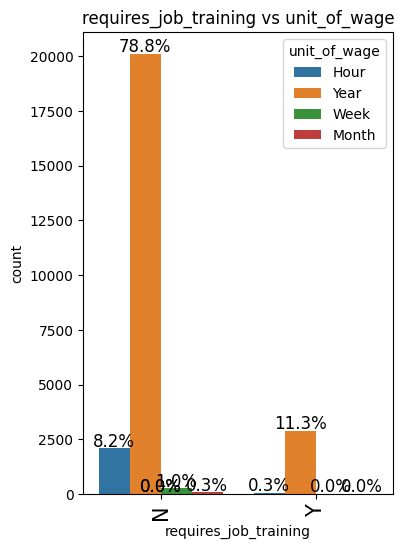



-----------------------------------------------------------------




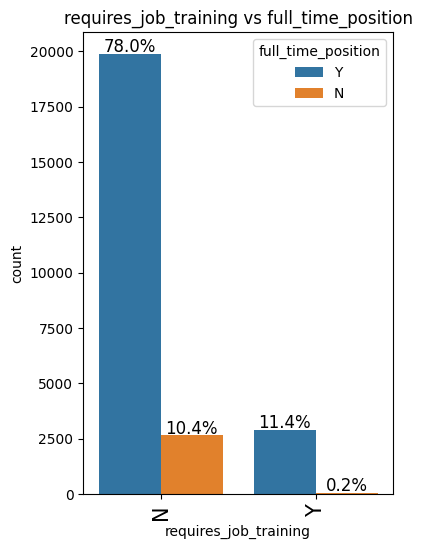



-----------------------------------------------------------------


Variable Name: region_of_employment:


-----------------------------------------------------------------




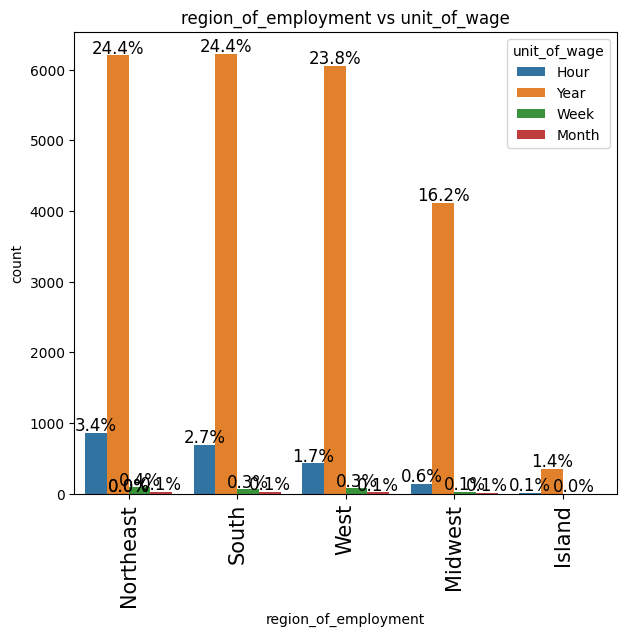



-----------------------------------------------------------------




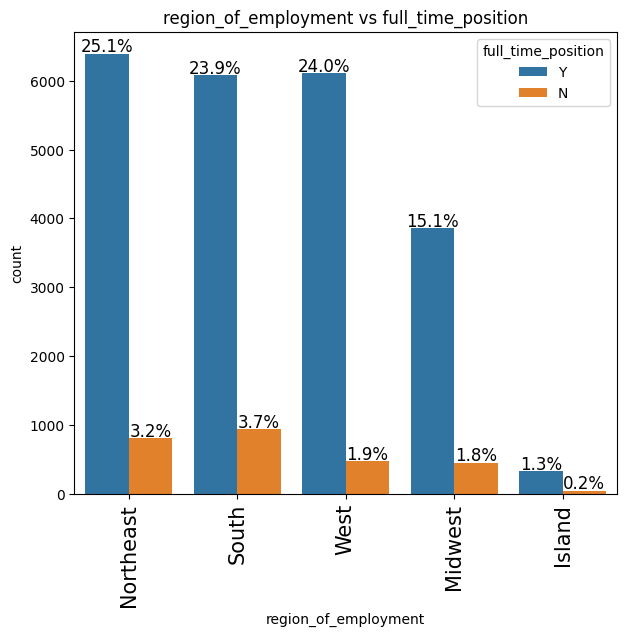



-----------------------------------------------------------------


Variable Name: unit_of_wage:


-----------------------------------------------------------------




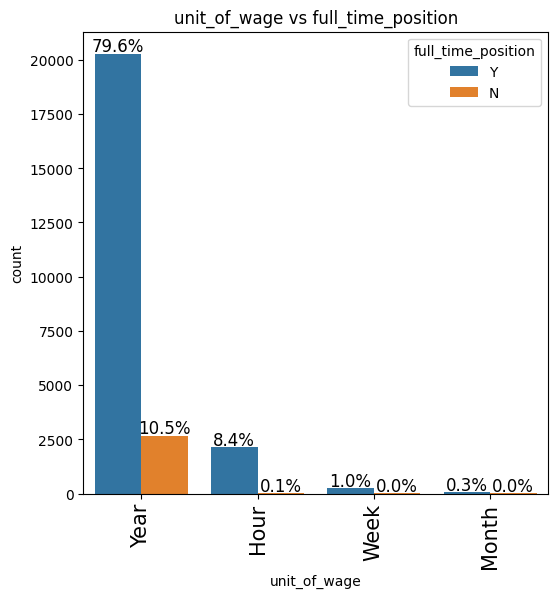



-----------------------------------------------------------------




In [ ]:
#Perform bivariate analysis for remaining variables
for i in range(1,len(obj_columns[1:])-1):
  print(f'Variable Name: {obj_columns[i]}:')
  print('\n\n-----------------------------------------------------------------\n\n')
  for j in range(i+1, len(obj_columns[1:])):
    labeled_barplot2(df, obj_columns[i], obj_columns[j], perc=True)
    plt.show()
    print('\n\n-----------------------------------------------------------------\n\n')


# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
#Create copy of original DataFrame
df_copy = df.copy()

## Negative Number of Employees Negative Number Abs Value

In [ ]:
#Check counts of negative numbers before applying absolute value
df_copy[df_copy['no_of_employees'] < 0]['no_of_employees'].value_counts()

,count
no_of_employees,
-11,9
-14,8
-26,7
-25,5
-17,4


In [ ]:
df_copy[df_copy['no_of_employees'] < 0].shape[0]

33

The negative numbers of the number of employees seem plausible and there are only 33 negative values out of the total 25,480 rows. Therefore rather than imputation and to avoid data leaks, a simple absolute value of these negative values should suffice to get more reasonable values.

In [ ]:
#Apply absolute value to all number of employees cells
df_copy['no_of_employees'] = df_copy['no_of_employees'].abs()

In [ ]:
#Check counts of negative numbers after applying absolute value
df_copy[df_copy['no_of_employees'] < 0]['no_of_employees'].value_counts()

,count
no_of_employees,


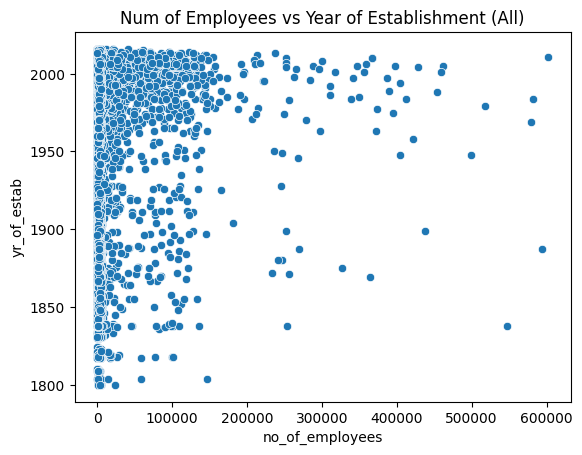

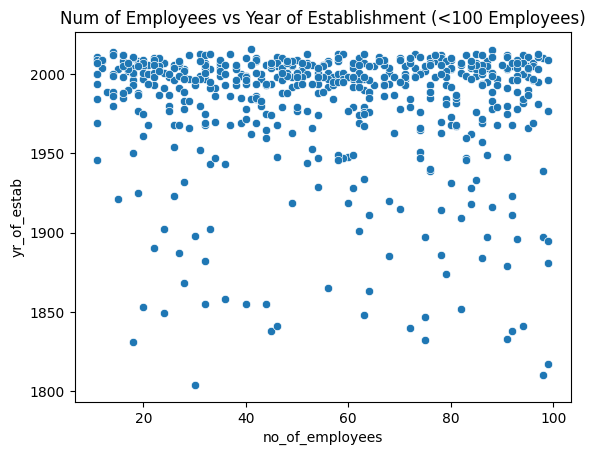

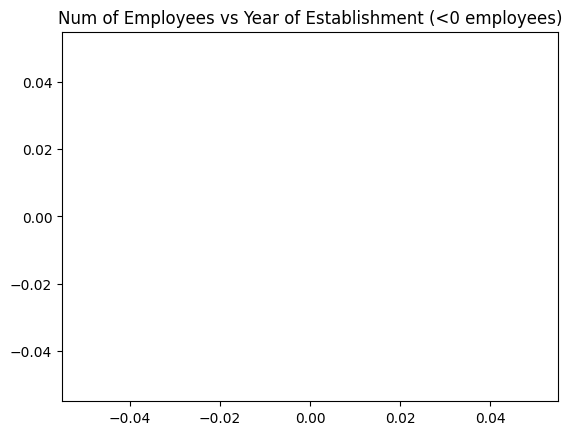

In [ ]:
#Check counts of negative numbers after applying absolute value
sns.scatterplot(data=df_copy, x='no_of_employees', y='yr_of_estab')
plt.title('Num of Employees vs Year of Establishment (All)')
plt.show()
sns.scatterplot(data=df_copy[df_copy['no_of_employees'] < 100], x='no_of_employees', y='yr_of_estab')
plt.title('Num of Employees vs Year of Establishment (<100 Employees)')
plt.show()
sns.scatterplot(data=df_copy[df_copy['no_of_employees'] < 0], x='no_of_employees', y='yr_of_estab')
plt.title('Num of Employees vs Year of Establishment (<0 employees)')
plt.show()

Negative values removed from number of employees.

## Drop case ID

In [ ]:
#Check to see if there are any repeating case ID numbers
df_copy['case_id'].nunique()

25480

All case ID numbers are unique and therefore can be dropped.

In [ ]:
#Drop case_id column
df_copy.drop('case_id', axis=1, inplace=True)
df_copy.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


## Feature Engineering

In [ ]:
#Set 'yes' 'no' and education level catagorical variables to one hot encoded or ranked numeric variables
job_exp = {'N': 0, 'Y': 1}
df_copy['has_job_experience'] = df_copy['has_job_experience'].map(job_exp)

req_job_train = {'N': 0, 'Y': 1}
df_copy['requires_job_training'] = df_copy['requires_job_training'].map(req_job_train)

full_time = {'N': 0, 'Y': 1}
df_copy['full_time_position'] = df_copy['full_time_position'].map(full_time)

case_status = {'Certified': 1, 'Denied': 0}
df_copy['case_status'] = df_copy['case_status'].map(case_status)

ed_of_emp = {'High School': 1, "Bachelor's": 2, "Master's": 3, "Doctorate": 4}
df_copy['education_of_employee'] = df_copy['education_of_employee'].map(ed_of_emp)

df_copy.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,1,0,0,14513,2007,West,592.203,Hour,1,0
1,Asia,3,1,0,2412,2002,Northeast,83425.650,Year,1,1
2,Asia,2,0,1,44444,2008,West,122996.860,Year,1,0
3,Asia,2,0,0,98,1897,West,83434.030,Year,1,0
4,Africa,3,1,0,1082,2005,South,149907.390,Year,1,1


## Data Split

In [ ]:
#Split data into train, validation, and test datasets
X = df_copy.drop('case_status', axis=1)
y = df_copy['case_status']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(15288, 10) (5096, 10) (5096, 10)


In [ ]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

# **Model Building**

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In this case, the recall score will be prioritzed in order to shortlist as many truly qualified applicants as possible.

The F1 score to get a good balance of precision and recall will be important as well in order to maximize truly qualified visa candidates.

## Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 77.61998041136141
Random forest: 84.5739471106758
GBM: 87.36532810969638
Adaboost: 88.52105778648382
Xgboost: 85.39666993143976
dtree: 73.30068560235064

Validation Performance:

Bagging: 0.7776145710928319
Random forest: 0.8331374853113983
GBM: 0.8766157461809636
Adaboost: 0.8804347826086957
Xgboost: 0.8513513513513513
dtree: 0.7485311398354877


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9862, Validation Score: 0.7776, Difference: 0.2086
Random forest: Training Score: 1.0000, Validation Score: 0.8331, Difference: 0.1669
GBM: Training Score: 0.8802, Validation Score: 0.8766, Difference: 0.0036
Adaboost: Training Score: 0.8875, Validation Score: 0.8804, Difference: 0.0070
Xgboost: Training Score: 0.9436, Validation Score: 0.8514, Difference: 0.0922
dtree: Training Score: 1.0000, Validation Score: 0.7485, Difference: 0.2515


In [ ]:
#Check Model Performance of Gradient Boost on training data
GBM_orig_train = model_performance_classification_sklearn(
    model=GradientBoostingClassifier(random_state=1).fit(X_train, y_train),
    predictors=X_train,
    target=y_train,
)
GBM_orig_train

,Accuracy,Recall,Precision,F1
0,0.757,0.880,0.783,0.829


In [ ]:
#Check Model Performance of Gradient Boost on validation data
GBM_orig_val = model_performance_classification_sklearn(
    model=GradientBoostingClassifier(random_state=1).fit(X_train, y_train),
    predictors=X_val,
    target=y_val,
)
GBM_orig_val

,Accuracy,Recall,Precision,F1
0,0.755,0.877,0.782,0.827


In [ ]:
#Check Model Performance of Adaboost  on training data
ada_orig_train = model_performance_classification_sklearn(
    model=AdaBoostClassifier(random_state=1).fit(X_train, y_train),
    predictors=X_train,
    target=y_train,
)
ada_orig_train

,Accuracy,Recall,Precision,F1
0,0.739,0.887,0.761,0.820


In [ ]:
#Check Model Performance of Adaboost  on validation data
ada_orig_val = model_performance_classification_sklearn(
    model=AdaBoostClassifier(random_state=1).fit(X_train, y_train),
    predictors=X_val,
    target=y_val,
)
ada_orig_val

,Accuracy,Recall,Precision,F1
0,0.738,0.880,0.763,0.818


For the original data, Gradient Boost and Ada Boost perform the best with a recall score of 88.02 and 88.75 training score and 87.66 and 88.04 validation score.

The other models show signs of overfitting.

When evaluation the accuracy, recall, precision, and F1 scores of both the gradient boost and adaboost methods, both score very well and the training and validation scores across the board are very high and match well.

## Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 19)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 75.78844270323214
Random forest: 81.32223310479922
GBM: 84.38785504407443
Adaboost: 80.01958863858961
Xgboost: 83.76101860920664
dtree: 73.09500489715965

Validation Performance:

Bagging: 0.7591069330199764
Random forest: 0.8146298472385429
GBM: 0.8396004700352526
Adaboost: 0.7664512338425382
Xgboost: 0.8328437132784959
dtree: 0.7215041128084606


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9808, Validation Score: 0.7591, Difference: 0.2217
Random forest: Training Score: 1.0000, Validation Score: 0.8146, Difference: 0.1854
GBM: Training Score: 0.8501, Validation Score: 0.8396, Difference: 0.0105
Adaboost: Training Score: 0.7663, Validation Score: 0.7665, Difference: -0.0001
Xgboost: Training Score: 0.9148, Validation Score: 0.8328, Difference: 0.0819
dtree: Training Score: 1.0000, Validation Score: 0.7215, Difference: 0.2785


In [ ]:
#Check Model Performance of Gradient Boost with oversampled data and training data
GBM_ov_train = model_performance_classification_sklearn(
    model=GradientBoostingClassifier(random_state=1).fit(X_train_over, y_train_over),
    predictors=X_train_over,
    target=y_train_over,
)
GBM_ov_train

,Accuracy,Recall,Precision,F1
0,0.803,0.850,0.777,0.812


In [ ]:
#Check Model Performance of Gradient Boost with oversampled data and validation data
GBM_ov_val = model_performance_classification_sklearn(
    model=GradientBoostingClassifier(random_state=1).fit(X_train_over, y_train_over),
    predictors=X_val,
    target=y_val,
)
GBM_ov_val

,Accuracy,Recall,Precision,F1
0,0.741,0.840,0.787,0.812


In [ ]:
#Check Model Performance of Ada Boost with oversampled data
ada_ov_train =model_performance_classification_sklearn(
    model=AdaBoostClassifier(random_state=1).fit(X_train_over, y_train_over),
    predictors=X_train_over,
    target=y_train_over,
)
ada_ov_train

,Accuracy,Recall,Precision,F1
0,0.769,0.766,0.770,0.768


In [ ]:
#Check Model Performance of Ada Boost with oversampled data
ada_ov_val = model_performance_classification_sklearn(
    model=AdaBoostClassifier(random_state=1).fit(X_train_over, y_train_over),
    predictors=X_val,
    target=y_val,
)
ada_ov_val

,Accuracy,Recall,Precision,F1
0,0.709,0.766,0.792,0.779


When oversampling the data and using the same methods to generate the models, GBM still performs best with a training score of 85 and a validation score of 84. The original data performance is still better with a score of 88 for training and validation.

Adaboost matches well with training and validation but drops sharply when complared tot he original data models.

When looking at accuracy, recall, precision, and F1, GBM still performs well across the board and generally matches well with the validation set.

The same can be said with adaboost albeit with lower scores vs the original data.

## Undersampled Data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 19)
After Under Sampling, the shape of train_y: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 60.63381947946163
Random forest: 67.25092122105426
GBM: 73.02059656336061
Adaboost: 71.05104534347
Xgboost: 68.29440285481556
dtree: 63.68697878282455

Validation Performance:

Bagging: 0.6157461809635723
Random forest: 0.6706815511163338
GBM: 0.7353113983548766
Adaboost: 0.7112220916568742
Xgboost: 0.6930082256169212
dtree: 0.6321974148061105


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9677, Validation Score: 0.6157, Difference: 0.3520
Random forest: Training Score: 1.0000, Validation Score: 0.6707, Difference: 0.3293
GBM: Training Score: 0.7519, Validation Score: 0.7353, Difference: 0.0166
Adaboost: Training Score: 0.7121, Validation Score: 0.7112, Difference: 0.0009
Xgboost: Training Score: 0.8763, Validation Score: 0.6930, Difference: 0.1833
dtree: Training Score: 1.0000, Validation Score: 0.6322, Difference: 0.3678


In [ ]:
#Check Model Performance of Gradient Boost with undersampled data
GBM_un_train = model_performance_classification_sklearn(
    model=GradientBoostingClassifier(random_state=1).fit(X_train_un, y_train_un),
    predictors=X_train,
    target=y_train,
)
GBM_un_train

,Accuracy,Recall,Precision,F1
0,0.728,0.746,0.829,0.785


In [ ]:
#Check Model Performance of Gradient Boost with undersampled data
GBM_un_val = model_performance_classification_sklearn(
    model=GradientBoostingClassifier(random_state=1).fit(X_train_un, y_train_un),
    predictors=X_val,
    target=y_val,
)
GBM_un_val

,Accuracy,Recall,Precision,F1
0,0.722,0.735,0.829,0.779


In [ ]:
#Check Model Performance of Ada Boost with undersampled data
ada_un_train = model_performance_classification_sklearn(
    model=AdaBoostClassifier(random_state=1).fit(X_train_un, y_train_un),
    predictors=X_train,
    target=y_train,
)
ada_un_train

,Accuracy,Recall,Precision,F1
0,0.698,0.713,0.813,0.759


In [ ]:
#Check Model Performance of Ada Boost with undersampled data
ada_un_val = model_performance_classification_sklearn(
    model=AdaBoostClassifier(random_state=1).fit(X_train_un, y_train_un),
    predictors=X_val,
    target=y_val,
)
ada_un_val

,Accuracy,Recall,Precision,F1
0,0.703,0.711,0.820,0.762


When the data is undersampled GB still performs best but declines sharply vs oversampled and original data.

Adaboost has a good match but score also drops compred to original and oversampled.

The rest of the models are overfitting.

When looking at accuracy, recall, precision, and F1 scores, both GBM and adaboost match well with training and validation sets and the scores are acceptable though not as high as both the oversampled and original data GBM and adaboost results.

# **Model Performance Improvement**

## Hyperparameter Tuning

Based on model performances using the original, oversampled, and undersmapled results, the best models to try to futher improve will be:

1. Original Data GBM
2. Original Data AdaBoost Method
3. Oversampled Data GBM
4. Oversampled Data AdaBoost Method

### Original Data Hyperparameter Tuning

In [ ]:
#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
    "max_depth": [1, 2, 3, 4, 5, 6, 7, 8, 9]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'init': [AdaBoostClassifier(random_state=1),
                                                 DecisionTreeClassifier(random_state=1)],
                                        'learning_rate': [0.01, 0.2, 0.05, 1],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8,
                                                      9],
                                        'max_features': [0.5, 0.7, 1],
                                        'n_estimators': array([125, 150]),
                                        'subsample': [0.8, 0.9, 1]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
        DecisionTreeClassifier(max_depth=4, random_state=1),
        DecisionTreeClassifier(max_depth=5, random_state=1),
        DecisionTreeClassifier(max_depth=6, random_state=1),
        DecisionTreeClassifier(max_depth=7, random_state=1),
        DecisionTreeClassifier(max_depth=8, random_state=1),
        DecisionTreeClassifier(max_depth=9, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(20), 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV score=0.9241919686581783:


In [ ]:
#Save GBM original data with hypertuning model to variable
GBM_hyp_mod_orig = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.2, max_depth=1, max_features=1,
                           n_estimators=np.int64(150), random_state=1,
                           subsample=0.8).fit(X_train, y_train)

In [ ]:
#Save AdaBoost original data with hypertuning model to variable
adb_hyp_mod_orig = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.05,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
).fit(X_train, y_train)

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("GBM", GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.2, max_depth=1, max_features=1,
                           n_estimators=np.int64(150), random_state=1,
                           subsample=0.8)))
models.append(("AdaBoost", AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.05,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)))


results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

GBM: 90.52889324191969
AdaBoost: 92.64446620959843

Validation Performance:

GBM: 0.8980611045828437
AdaBoost: 0.9233254994124559


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

GBM: Training Score: 0.9006, Validation Score: 0.8981, Difference: 0.0025
AdaBoost: Training Score: 0.9226, Validation Score: 0.9233, Difference: -0.0007


In [ ]:
#Check GBM original data with hypertuning model training data performance
GBM_orig_Hyp_train = model_performance_classification_sklearn(
    model=GBM_hyp_mod_orig,
    predictors=X_train,
    target=y_train,
)
GBM_orig_Hyp_train

,Accuracy,Recall,Precision,F1
0,0.737,0.901,0.754,0.821


In [ ]:
#Check GBM original data with hypertuning model validation data performance
GBM_orig_Hyp_val = model_performance_classification_sklearn(
    model=GBM_hyp_mod_orig,
    predictors=X_val,
    target=y_val,
)
GBM_orig_Hyp_val

,Accuracy,Recall,Precision,F1
0,0.736,0.898,0.754,0.820


In [ ]:
#Check Adaboost original data with hypertuning model training data performance
ada_orig_Hyp_train = model_performance_classification_sklearn(
    model=adb_hyp_mod_orig,
    predictors=X_train,
    target=y_train,
)
ada_orig_Hyp_train

,Accuracy,Recall,Precision,F1
0,0.722,0.923,0.732,0.816


In [ ]:
#Check Adaboost original data with hypertuning model validation data performance
ada_orig_Hyp_val = model_performance_classification_sklearn(
    model=adb_hyp_mod_orig,
    predictors=X_val,
    target=y_val,
)
ada_orig_Hyp_val

,Accuracy,Recall,Precision,F1
0,0.729,0.923,0.738,0.820


After hyperparameter tuning for the original data GBM and Adaboost:

- GBM gained minor improvements with a recall score of 88 before tuning and 90 after. Slight drops in all other metrics were observed after tuning.

- AdaBoost had more of an improvement witht eh recall score of 92 after tuning and 88 before. All other metrics after tuning dropped slightly but are similar to the non tuned adaboost result.

### Oversampled Data Hypertuning

In [ ]:
#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
    "max_depth": [1, 2, 3, 4, 5, 6, 7, 8, 9]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'init': [AdaBoostClassifier(random_state=1),
                                                 DecisionTreeClassifier(random_state=1)],
                                        'learning_rate': [0.01, 0.2, 0.05, 1],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8,
                                                      9],
                                        'max_features': [0.5, 0.7, 1],
                                        'n_estimators': array([125, 150]),
                                        'subsample': [0.8, 0.9, 1]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
        DecisionTreeClassifier(max_depth=4, random_state=1),
        DecisionTreeClassifier(max_depth=5, random_state=1),
        DecisionTreeClassifier(max_depth=6, random_state=1),
        DecisionTreeClassifier(max_depth=7, random_state=1),
        DecisionTreeClassifier(max_depth=8, random_state=1),
        DecisionTreeClassifier(max_depth=9, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(10), 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=8, random_state=1)} with CV score=0.8354554358472086:


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("GBM", GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_depth=6, max_features=0.7,
                           n_estimators=np.int64(150), random_state=1,
                           subsample=0.9)))
models.append(("AdaBoost", AdaBoostClassifier(
    random_state=1,
    n_estimators=10,
    learning_rate=0.2,
    estimator=DecisionTreeClassifier(max_depth=8, random_state=1),
)))


results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

GBM: 84.48579823702251
AdaBoost: 82.80117531831539

Validation Performance:

GBM: 0.8434195064629847
AdaBoost: 0.8234430082256169


In [ ]:
#Save GBM oversampled data with hypertuning model to variable
GBM_hyp_mod_ov = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_depth=6, max_features=0.7,
                           n_estimators=np.int64(150), random_state=1,
                           subsample=0.9).fit(X_train_over, y_train_over)

In [ ]:
#Save Adaboost oversampled data with hypertuning model to variable
adb_hyp_mod_ov = AdaBoostClassifier(
    random_state=1,
    n_estimators=10,
    learning_rate=0.2,
    estimator=DecisionTreeClassifier(max_depth=8, random_state=1),
).fit(X_train_over, y_train_over)

In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

GBM: Training Score: 0.8695, Validation Score: 0.8434, Difference: 0.0261
AdaBoost: Training Score: 0.8486, Validation Score: 0.8234, Difference: 0.0251


In [ ]:
#Check GBM oversampled data with hypertuning model training data performance
GBM_ov_Hyp_train = model_performance_classification_sklearn(
    model=GBM_hyp_mod_ov,
    predictors=X_train_over,
    target=y_train_over,
)
GBM_ov_Hyp_train

,Accuracy,Recall,Precision,F1
0,0.828,0.870,0.803,0.835


In [ ]:
#Check GBM oversampled data with hypertuning model validation data performance
GBM_ov_Hyp_val = model_performance_classification_sklearn(
    model=GBM_hyp_mod_ov,
    predictors=X_val,
    target=y_val,
)
GBM_ov_Hyp_val

,Accuracy,Recall,Precision,F1
0,0.748,0.843,0.792,0.817


In [ ]:
#Check Adaboost oversampled data with hypertuning model training data performance
ada_ov_Hyp_train = model_performance_classification_sklearn(
    model=adb_hyp_mod_ov,
    predictors=X_train_over,
    target=y_train_over,
)
ada_ov_Hyp_train

,Accuracy,Recall,Precision,F1
0,0.808,0.849,0.785,0.816


In [ ]:
#Check Adaboost oversampled data with hypertuning model validation data performance
ada_ov_Hyp_val = model_performance_classification_sklearn(
    model=adb_hyp_mod_ov,
    predictors=X_val,
    target=y_val,
)
ada_ov_Hyp_val

,Accuracy,Recall,Precision,F1
0,0.742,0.823,0.797,0.810


# **Model Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        GBM_orig_train.T,
        GBM_orig_Hyp_train.T,
        GBM_ov_train.T,
        GBM_ov_Hyp_train.T,
        ada_orig_train.T,
        ada_orig_Hyp_train.T,
        ada_ov_train.T,
        ada_ov_Hyp_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "GBM Original",
    "GBM Original HT",
    "GBM Oversampled",
    "GBM Oversampled HT",
    "AdaBoost Original",
    "AdaBoost Original HT",
    "AdaBoost Oversampled",
    "AdaBoost Oversampled HT"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,GBM Original,GBM Original HT,GBM Oversampled,GBM Oversampled HT,AdaBoost Original,AdaBoost Original HT,AdaBoost Oversampled,AdaBoost Oversampled HT
Accuracy,0.757,0.737,0.803,0.828,0.739,0.722,0.769,0.808
Recall,0.880,0.901,0.850,0.870,0.887,0.923,0.766,0.849
Precision,0.783,0.754,0.777,0.803,0.761,0.732,0.770,0.785
F1,0.829,0.821,0.812,0.835,0.820,0.816,0.768,0.816


In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        GBM_orig_val.T,
        GBM_orig_Hyp_val.T,
        GBM_ov_val.T,
        GBM_ov_Hyp_val.T,
        ada_orig_val.T,
        ada_orig_Hyp_val.T,
        ada_ov_val.T,
        ada_ov_Hyp_val.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "GBM Original",
    "GBM Original HT",
    "GBM Oversampled",
    "GBM Oversampled HT",
    "AdaBoost Original",
    "AdaBoost Original HT",
    "AdaBoost Oversampled",
    "AdaBoost Oversampled HT"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,GBM Original,GBM Original HT,GBM Oversampled,GBM Oversampled HT,AdaBoost Original,AdaBoost Original HT,AdaBoost Oversampled,AdaBoost Oversampled HT
Accuracy,0.755,0.736,0.741,0.748,0.738,0.729,0.709,0.742
Recall,0.877,0.898,0.840,0.843,0.880,0.923,0.766,0.823
Precision,0.782,0.754,0.787,0.792,0.763,0.738,0.792,0.797
F1,0.827,0.820,0.812,0.817,0.818,0.820,0.779,0.810


Looking at all tests and all metrics, the Adaboost on the original data with hyperparameter tuning performs best with the highest recall and second highest F1 score indicating a good balance of recall and precision.

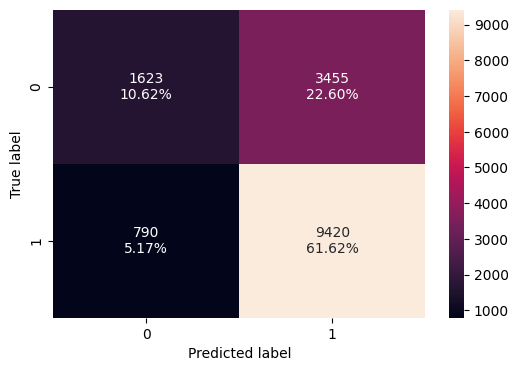

In [ ]:
#Check chosen model confusion matrix of training data
confusion_matrix_sklearn(adb_hyp_mod_orig, X_train, y_train)

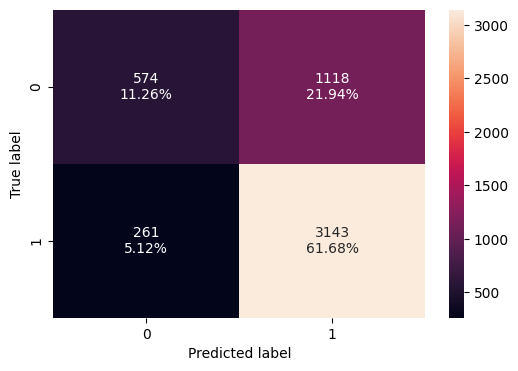

In [ ]:
#Check chosen model confusion matrix of validation data
confusion_matrix_sklearn(adb_hyp_mod_orig, X_val, y_val)

In [ ]:
# Let's check the performance on test set
ada_orig_hyp_test = model_performance_classification_sklearn(adb_hyp_mod_orig, X_test, y_test)
ada_orig_hyp_test

,Accuracy,Recall,Precision,F1
0,0.717,0.921,0.728,0.813


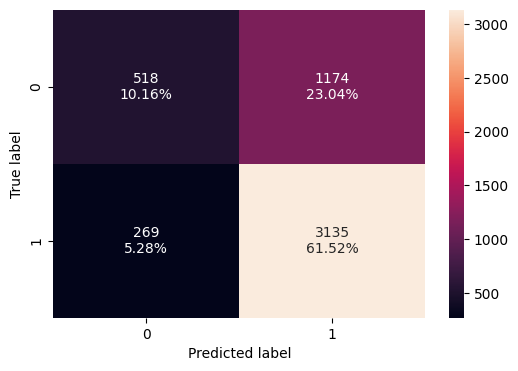

In [ ]:
#Check confusion matrix performance on test set
confusion_matrix_sklearn(adb_hyp_mod_orig, X_test, y_test)

The performance of the model using the test data is in line with the performance of the validation and training data.

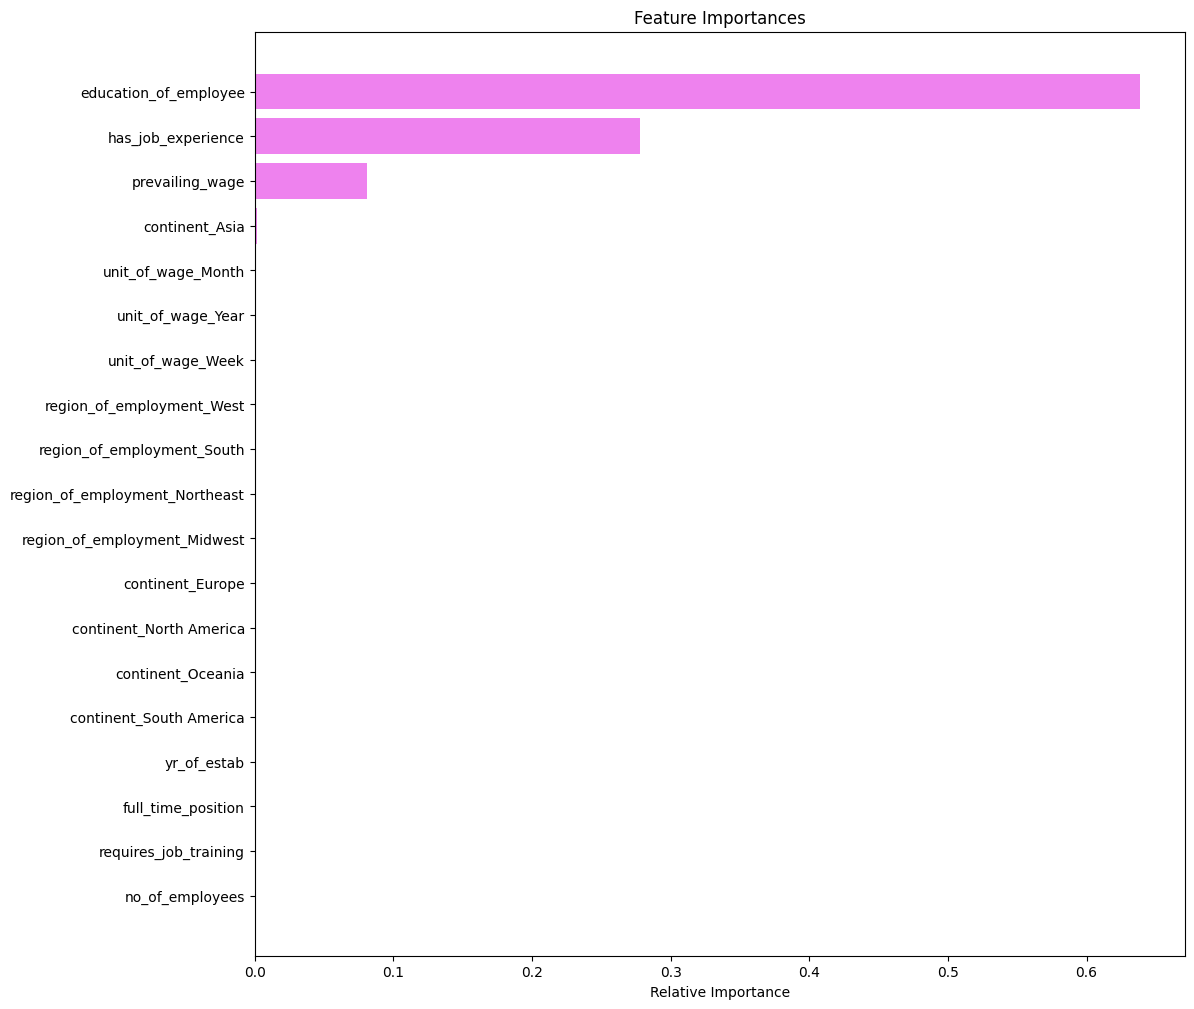

In [ ]:
#Create feature of importance graph
feature_names = X_train.columns
importances = adb_hyp_mod_orig.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Actionable Insights and Recommendations**

*  Based on the feature importance, visa applicants approval or denial is highly dependent on their level of education, whether they have job experience, and that applicants prevailing wage.

* For applicant education, applicants with college degrees are more likely to be certified (Bachelor's, Masters, or Doctorate)

* For applicant job experience, an applicant with job experience is more likely to have their application certified.

* For applicant prevailing wage, applcants with prevailing wage around $70,000 are more likely to have their visa approved.



___